In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [2]:
np.random.seed(10)
tf.keras.utils.set_random_seed(10)

In [3]:
# wczytanie danych

# dane
(images, labels), _ = tf.keras.datasets.fashion_mnist.load_data()

# nazwy klas (do wyświetlania)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
# podzial danych

X_train_original, X_test_original, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.1,
    random_state=10,
    stratify=labels)

print("Zakres oryginalnych danych treningowych:")
print("min:", X_train_original.min())
print("max:", X_train_original.max())


Zakres oryginalnych danych treningowych:
min: 0
max: 255
Zakres oryginalnych danych treningowych:
min: 0
max: 255


In [5]:
# przygotownie danych

# normalizacja - zapisujemy wynik do nowych zmiennych
X_train = X_train_original.astype("float32") / 255.0
X_test = X_test_original.astype("float32") / 255.0

# dodanie kanalu (CNN wymaga 4D: wysokosc, szerokosc, kanal)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Zakres danych po normalizacji:")
print("min:", X_train.min())
print("max:", X_train.max())


Zakres danych po normalizacji:
min: 0.0
max: 1.0
Zakres danych po normalizacji:
min: 0.0
max: 1.0


In [6]:
# osobny zbior walidacyjny

# ten sam zbior walidacyjny bedzie uzyty przy obu modelach
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=10,
    stratify=y_train)

print("Zbior treningowy:", X_train_model.shape)
print("Zbior walidacyjny:", X_val.shape)
print("Zbior testowy:", X_test.shape)


Zbior treningowy: (48600, 28, 28, 1)
Zbior walidacyjny: (5400, 28, 28, 1)
Zbior testowy: (6000, 28, 28, 1)
Zbior treningowy: (48600, 28, 28, 1)
Zbior walidacyjny: (5400, 28, 28, 1)
Zbior testowy: (6000, 28, 28, 1)


In [7]:
# funkcja do wyswietlania historii uczenia

def pokaz_porownanie_historii(history_basic, history_aug):
    """
    Porownuje przebieg uczenia dwoch modeli:
    modelu prostego i modelu z augmentacja.
    """

    # loss
    plt.figure(figsize=(12, 5))

    plt.plot(
        range(1, len(history_basic.history['loss']) + 1),
        history_basic.history['loss'],
        label='Prosty CNN - loss')
    plt.plot(
        range(1, len(history_basic.history['val_loss']) + 1),
        history_basic.history['val_loss'],
        label='Prosty CNN - val_loss')

    plt.plot(
        range(1, len(history_aug.history['loss']) + 1),
        history_aug.history['loss'],
        label='CNN + Albumentations - loss')
    plt.plot(
        range(1, len(history_aug.history['val_loss']) + 1),
        history_aug.history['val_loss'],
        label='CNN + Albumentations - val_loss')

    plt.title("Porownanie funkcji straty")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

    # accuracy
    plt.figure(figsize=(12, 5))

    plt.plot(
        range(1, len(history_basic.history['accuracy']) + 1),
        history_basic.history['accuracy'],
        label='Prosty CNN - accuracy')
    plt.plot(
        range(1, len(history_basic.history['val_accuracy']) + 1),
        history_basic.history['val_accuracy'],
        label='Prosty CNN - val_accuracy')

    plt.plot(
        range(1, len(history_aug.history['accuracy']) + 1),
        history_aug.history['accuracy'],
        label='CNN + Albumentations - accuracy')
    plt.plot(
        range(1, len(history_aug.history['val_accuracy']) + 1),
        history_aug.history['val_accuracy'],
        label='CNN + Albumentations - val_accuracy')

    plt.title("Porownanie accuracy")
    plt.xlabel("Epoka")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()


In [8]:
# funkcja do macierzy omylek

def pokaz_confusion_matrix(model, X_checked, y_checked, title):
    predictions_proba = model.predict(X_checked)
    predictions = np.argmax(predictions_proba, axis=1)

    cm = confusion_matrix(y_checked, predictions)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names)

    plt.title(title)
    plt.xlabel("Predykcja")
    plt.ylabel("Wartosc prawdziwa")
    plt.show()


In [9]:
# prosty model

f_mnist_model = Sequential([
    Conv2D(32, 3, padding='same', activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')])


C:\Users\atrel\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\atrel\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# kompilacja modelu

f_mnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

f_mnist_model.summary()


Model: "sequential"

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# trening modelu

history = f_mnist_model.fit(
    X_train_model,
    y_train_model,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val))


Epoch 1/20
Epoch 1/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8015 - loss: 0.5593 - val_accuracy: 0.8776 - val_loss: 0.3402
Epoch 2/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8015 - loss: 0.5593 - val_accuracy: 0.8776 - val_loss: 0.3402
Epoch 2/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8729 - loss: 0.3568 - val_accuracy: 0.8959 - val_loss: 0.2891
Epoch 3/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8729 - loss: 0.3568 - val_accuracy: 0.8959 - val_loss: 0.2891
Epoch 3/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8889 - loss: 0.3072 - val_accuracy: 0.9069 - val_loss: 0.2583
Epoch 4/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8889 - loss: 0.3072 - val_accuracy: 0.9069 - val_loss: 0.2583
Epoch 4/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9008 - loss: 0.2745 - val_accuracy: 0.9146 - val_loss: 0.2411
Epoch 5/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9008 - loss

In [12]:
# ocena prostego modelu

loss_basic, accuracy_basic = f_mnist_model.evaluate(X_test, y_test)

print("Loss modelu prostego:", loss_basic)
print("Accuracy modelu prostego:", accuracy_basic)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9248 - loss: 0.2805
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9248 - loss: 0.2805
Loss modelu prostego: 0.2805229425430298
Accuracy modelu prostego: 0.924833357334137
Loss modelu prostego: 0.2805229425430298
Accuracy modelu prostego: 0.924833357334137


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


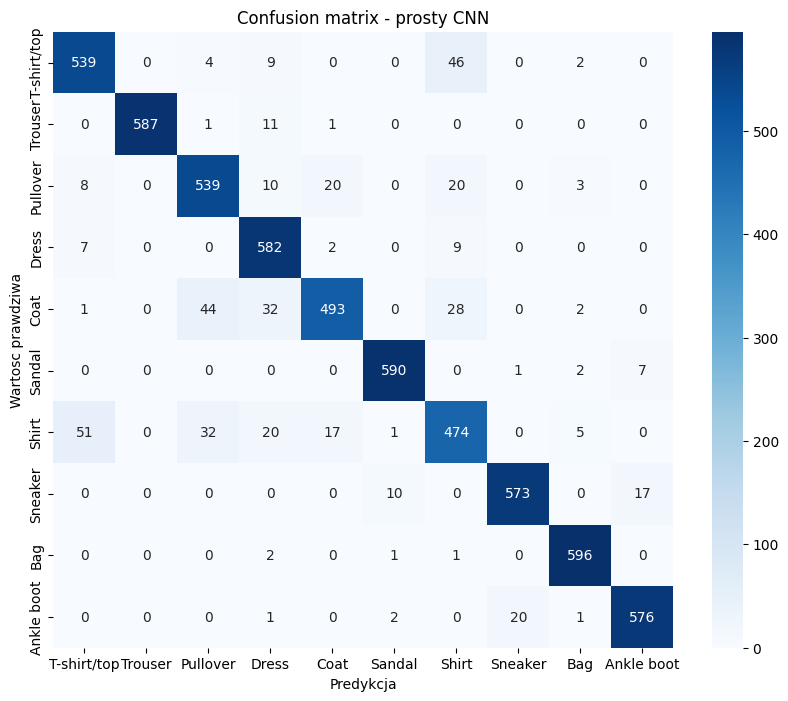

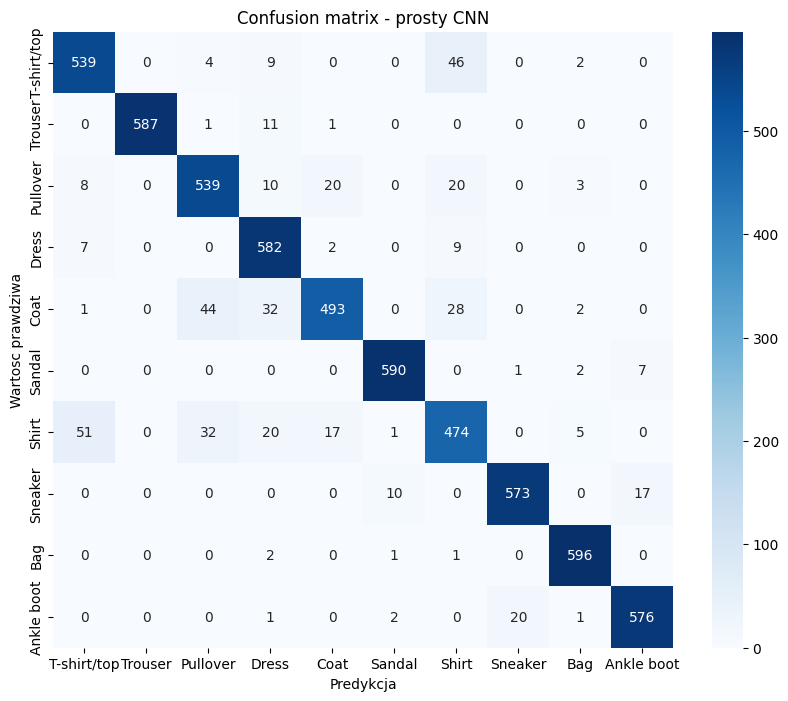

In [13]:
# macierz omylek dla prostego modelu

pokaz_confusion_matrix(
    f_mnist_model,
    X_test,
    y_test,
    "Confusion matrix - prosty CNN")


In [14]:
# zapisanie modelu

f_mnist_model.save("fashion_mnist_model_basic.keras")


In [15]:
loaded_model = load_model("fashion_mnist_model_basic.keras")


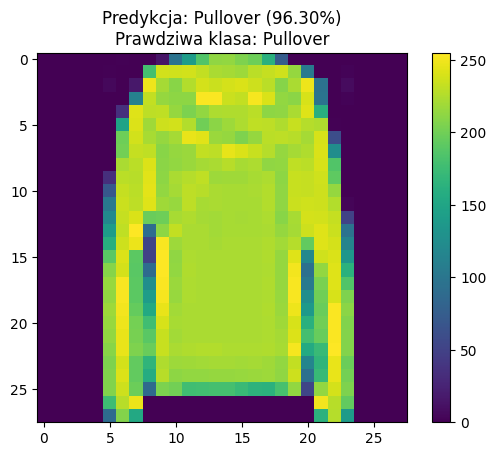

{'predykcja': 'Pullover',
 'prawdziwa_klasa': 'Pullover',
 'pewnosc': 0.9629690051078796,
 'prawdopodobienstwa': array([1.1015881e-06, 2.4781997e-08, 9.6296901e-01, 4.4143209e-09,
        3.6985092e-02, 2.5683487e-11, 4.4736240e-05, 1.9998846e-15,
        3.7137674e-08, 1.1732841e-14], dtype=float32)}

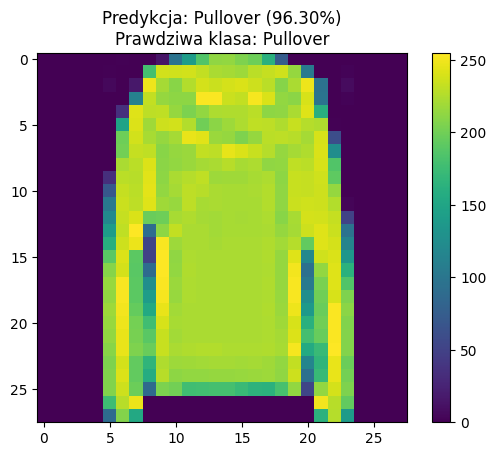

{'predykcja': 'Pullover',
 'prawdziwa_klasa': 'Pullover',
 'pewnosc': 0.9629690051078796,
 'prawdopodobienstwa': array([1.1015881e-06, 2.4781997e-08, 9.6296901e-01, 4.4143209e-09,
        3.6985092e-02, 2.5683487e-11, 4.4736240e-05, 1.9998846e-15,
        3.7137674e-08, 1.1732841e-14], dtype=float32)}

In [16]:
def przewidz_klase(index, model=loaded_model):
    """
    Funkcja przyjmuje indeks obrazu ze zbioru testowego,
    pokazuje obraz i zwraca klase przewidziana przez model.
    """

    obraz = X_test[index]
    obraz_do_wyswietlenia = X_test_original[index]
    prawdziwa_klasa = y_test[index]

    predykcja = model.predict(np.expand_dims(obraz, axis=0), verbose=0)

    przewidziana_klasa = np.argmax(predykcja)
    pewnosc = np.max(predykcja)

    plt.imshow(obraz_do_wyswietlenia, cmap="viridis")
    plt.colorbar()
    plt.title(
        f"Predykcja: {class_names[przewidziana_klasa]} ({pewnosc:.2%})\n"
        f"Prawdziwa klasa: {class_names[prawdziwa_klasa]}")
    plt.show()

    return {
        "predykcja": class_names[przewidziana_klasa],
        "prawdziwa_klasa": class_names[prawdziwa_klasa],
        "pewnosc": float(pewnosc),
        "prawdopodobienstwa": predykcja[0]}


# przyklad
przewidz_klase(0)


In [17]:
# MODEL Z AUGMENTACJA Z UZYCIEM ALBUMENTATIONS - sztucznie zwiekszamy dane

import albumentations as A

# definiujemy transformacje augmentacji
augmentacja = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.03,
        rotate_limit=5,
        p=0.5)])


# funkcja tworzy powiekszony zbior danych:
# bierze oryginalne obrazy
# dla kazdego tworzy dodatkowa, lekko zmieniona wersje
def zrob_augumentacje(X, y):
    X_aug = []
    y_aug = []

    for obraz, etykieta in zip(X, y):
        # dodajemy oryginalny obraz
        X_aug.append(obraz)
        y_aug.append(etykieta)

        # Albumentations na obrazie 2D
        obraz_2d = obraz.reshape(28, 28)

        # tworzymy obraz
        obraz_aug = augmentacja(image=obraz_2d)["image"]

        # dodajemy kanal z powrotem
        obraz_aug = obraz_aug.reshape(28, 28, 1)

        X_aug.append(obraz_aug)
        y_aug.append(etykieta)

    return np.array(X_aug), np.array(y_aug)


# tworzymy rozszerzony zbior treningowy
# walidacja zostaje bez augmentacji, zeby sprawdzac model na prawdziwych danych
X_train_aug, y_train_aug = zrob_augumentacje(X_train_model, y_train_model)

print("Rozmiar przed augmentacja:", X_train_model.shape)
print("Rozmiar po augmentacji:", X_train_aug.shape)


C:\Users\atrel\anaconda3\envs\tf\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\atrel\anaconda3\envs\tf\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Rozmiar przed augmentacja: (48600, 28, 28, 1)
Rozmiar po augmentacji: (97200, 28, 28, 1)
Rozmiar przed augmentacja: (48600, 28, 28, 1)
Rozmiar po augmentacji: (97200, 28, 28, 1)


In [18]:
# model CNN trenowany na danych z Albumentations

f_mnist_model_aug = Sequential([
    Conv2D(32, 3, padding='same', activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, 3, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.30),

    Conv2D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.35),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(10, activation='softmax')])


C:\Users\atrel\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\atrel\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# kompilacja nowego modelu

f_mnist_model_aug.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

f_mnist_model_aug.summary()


Model: "sequential_1"

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 585,066 (2.23 MB)

 Total params: 585,066 (2.23 MB)

 Trainable params: 584,618 (2.23 MB)

 Trainable params: 584,618 (2.23 MB)

 Non-trainable params: 448 (1.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
# trening nowego modelu

history_aug = f_mnist_model_aug.fit(
    X_train_aug,
    y_train_aug,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val))


Epoch 1/30
Epoch 1/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 158s 204ms/step - accuracy: 0.7959 - loss: 0.5625 - val_accuracy: 0.8887 - val_loss: 0.2983
Epoch 2/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 158s 204ms/step - accuracy: 0.7959 - loss: 0.5625 - val_accuracy: 0.8887 - val_loss: 0.2983
Epoch 2/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 159s 209ms/step - accuracy: 0.8792 - loss: 0.3324 - val_accuracy: 0.9059 - val_loss: 0.2511
Epoch 3/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 159s 209ms/step - accuracy: 0.8792 - loss: 0.3324 - val_accuracy: 0.9059 - val_loss: 0.2511
Epoch 3/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 162s 213ms/step - accuracy: 0.8976 - loss: 0.2823 - val_accuracy: 0.9196 - val_loss: 0.2240
Epoch 4/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 162s 213ms/step - accuracy: 0.8976 - loss: 0.2823 - val_accuracy: 0.9196 - val_loss: 0.2240
Epoch 4/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 160s 211ms/step - accuracy: 0.9076 - loss: 0.2517 - val_accuracy: 0.9237 - val_loss: 0.2156
Epoch 5/30
760/760 ━━━━━━━━━━━━━━━━━━━━ 160s 211ms/step - accurac

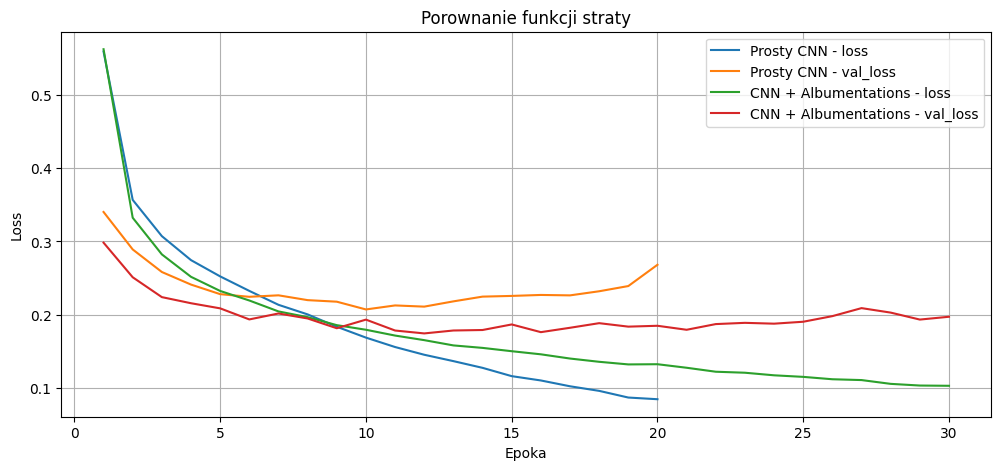

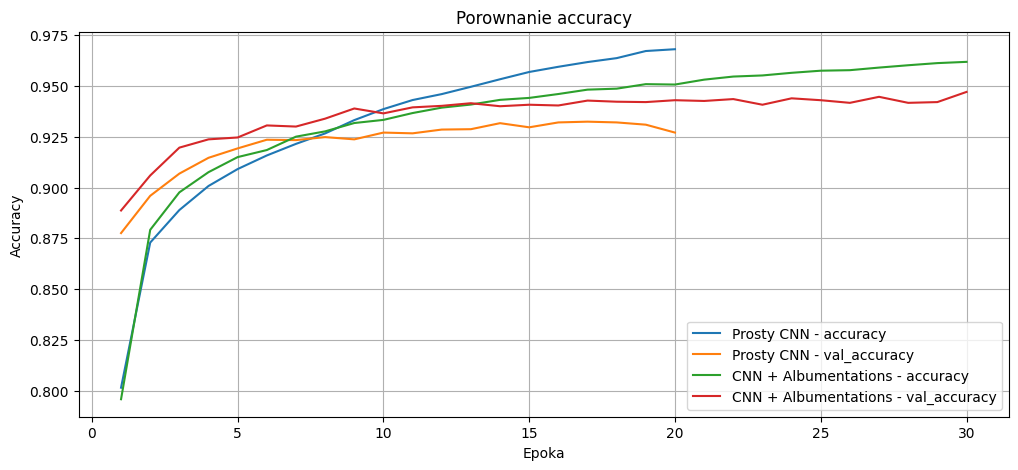

In [21]:
# porownanie historii uczenia obu modeli

pokaz_porownanie_historii(history, history_aug)


In [22]:
# ocena nowego modelu

loss_aug, accuracy_aug = f_mnist_model_aug.evaluate(X_test, y_test)

print("Loss modelu ulepszonego:", loss_aug)
print("Accuracy modelu ulepszonego:", accuracy_aug)


188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9380 - loss: 0.2051
Loss modelu ulepszonego: 0.2050633579492569
Accuracy modelu ulepszonego: 0.9380000233650208


188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step


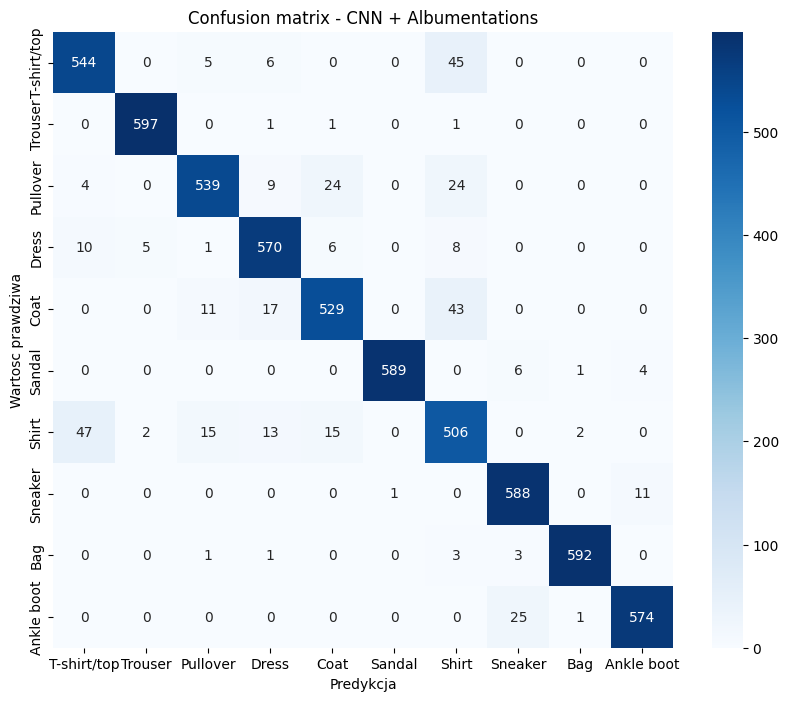

In [23]:
# macierz omylek dla modelu z augmentacja

pokaz_confusion_matrix(
    f_mnist_model_aug,
    X_test,
    y_test,
    "Confusion matrix - CNN + Albumentations")


In [24]:
# zapisanie modelu z augmentacja

f_mnist_model_aug.save("fashion_mnist_model_aug_albumentations.keras")


In [25]:
# porownanie modeli

porownanie = pd.DataFrame({
    "Model": [
        "Prosty CNN",
        "CNN + Albumentations"],
    "Loss": [
        loss_basic,
        loss_aug],
    "Accuracy": [
        accuracy_basic,
        accuracy_aug],
    "Epoki": [
        len(history.history["loss"]),
        len(history_aug.history["loss"])]})

porownanie


,Model,Loss,Accuracy,Epoki
0,Prosty CNN,0.280523,0.924833,20
1,CNN + Albumentations,0.205063,0.938000,30
